**Predicting the selling price of a car using historical data.**

### **STEP 1 — Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **STEP 2 — Load Dataset | Understanding**

In [5]:
df = pd.read_csv("cardetails.csv")
df.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [7]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [9]:
df.shape

(8128, 13)

### **STEP 3 — Data Cleaning**

In [10]:
# If the null values were less, I would have filled up with fillna.
# df.fillna(method='ffill', inplace=True)

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [13]:
# Ealier it was (8128, 13) after removing null.

df.shape

(7906, 13)

In [14]:
df.drop(columns=["torque"], inplace=True)

In [15]:
df.head(1)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0


In [16]:
# Duplicated check

df.duplicated().sum()

np.int64(1189)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(6717, 12)

In [19]:
for col in df.columns:
  print(f"Unique Values of + {col}")
  print(df[col].unique())
  print("===========================================\n")

Unique Values of + name
['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' ... 'Tata Nexon 1.5 Revotorq XT'
 'Ford Freestyle Titanium Plus Diesel BSIV'
 'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV']

Unique Values of + year
[2014 2006 2010 2007 2017 2001 2011 2013 2005 2009 2016 2012 2002 2015
 2018 2019 2008 2020 1999 2000 2003 2004 1994 1998 1997 1995 1996]

Unique Values of + selling_price
[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000   730000   650000   330000   366000
  1149000   425000  2100000   925000   675000   819999   390000  1500000
   700000  1450000  1090000   850000  1650000  1750000  1590000  1689999
  1425000   265000   190000   630000   540000   448000   745000  1025000
   235000  1700000  1200000   610000  2500000   484999   

In [20]:
def get_brand_names(x):
  return x.split(" ")[0]

In [21]:
df["name"] = df["name"].apply(get_brand_names)

In [22]:
df["mileage"] = df["mileage"].apply(get_brand_names)

In [23]:
df["engine"] = df["engine"].apply(get_brand_names)

In [24]:
df["max_power"] = df["max_power"].apply(get_brand_names)

In [25]:
df["name"].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [26]:
df["name"].nunique()

31

In [27]:
df["mileage"].unique()

array(['23.4', '21.14', '17.7', '23.0', '16.1', '20.14', '17.3', '23.59',
       '20.0', '19.01', '19.3', '18.9', '18.15', '24.52', '19.7', '22.54',
       '21.0', '25.5', '26.59', '21.5', '20.3', '21.4', '24.7', '18.2',
       '16.8', '24.3', '14.0', '18.6', '33.44', '23.95', '17.0', '20.63',
       '13.93', '16.0', '17.8', '18.5', '12.55', '12.99', '14.8', '13.5',
       '26.0', '20.65', '27.3', '11.36', '17.68', '14.28', '18.53',
       '14.84', '21.12', '20.36', '21.27', '18.16', '22.0', '25.1',
       '20.51', '21.66', '25.2', '22.9', '16.02', '20.54', '22.77',
       '15.71', '23.1', '19.02', '19.81', '26.2', '16.47', '15.04',
       '19.1', '21.79', '18.8', '21.21', '15.37', '11.79', '19.0', '14.3',
       '15.8', '15.1', '19.09', '22.32', '21.9', '14.53', '21.63',
       '20.85', '20.45', '19.67', '23.01', '20.77', '17.92', '17.01',
       '22.37', '19.33', '9.5', '12.83', '22.48', '16.78', '14.67',
       '15.0', '13.96', '18.0', '12.07', '26.21', '10.8', '16.3', '13.6',
     

In [28]:
df["engine"].unique()

array(['1248', '1498', '1497', '1396', '1298', '1197', '1061', '796',
       '1364', '1399', '1461', '993', '1198', '1199', '998', '1591',
       '2179', '1368', '2982', '2494', '2143', '2477', '1462', '2755',
       '1968', '1798', '1196', '1373', '1598', '1998', '1086', '1194',
       '1172', '1405', '1582', '999', '2487', '1999', '3604', '2987',
       '1995', '1451', '1969', '2967', '2497', '1797', '1991', '2362',
       '1493', '1599', '1341', '1794', '799', '1193', '2696', '1495',
       '1186', '1047', '2498', '2956', '2523', '1120', '624', '1496',
       '1984', '2354', '814', '793', '1799', '936', '1956', '1997',
       '1499', '1948', '2997', '2489', '2499', '2609', '2953', '1150',
       '1994', '1388', '1527', '2199', '995', '2993', '1586', '1390',
       '909', '2393', '3198', '1339', '2835', '2092', '1595', '2496',
       '1596', '1597', '2596', '2148', '1299', '1590', '2231', '2694',
       '2200', '1795', '1896', '1796', '1422', '1489', '2359', '2197',
       '2999', '1

In [29]:
df["max_power"].unique()

array(['74', '103.52', '78', '90', '88.2', '81.86', '57.5', '37', '67.1',
       '68.1', '108.45', '60', '73.9', '67', '82', '88.5', '46.3',
       '88.73', '64.1', '98.6', '88.8', '83.81', '83.1', '47.3', '73.8',
       '34.2', '35', '81.83', '40.3', '121.3', '138.03', '160.77',
       '117.3', '116.3', '83.14', '67.05', '168.5', '100', '120.7',
       '98.63', '175.56', '103.25', '171.5', '100.6', '174.33', '187.74',
       '170', '78.9', '88.76', '86.8', '108.495', '108.62', '93.7',
       '103.6', '98.59', '189', '67.04', '68.05', '58.2', '82.85',
       '81.80', '73', '120', '94.68', '160', '65', '155', '69.01',
       '126.32', '138.1', '83.8', '126.2', '98.96', '62.1', '86.7', '188',
       '214.56', '177', '280', '148.31', '254.79', '190', '177.46', '204',
       '141', '117.6', '241.4', '282', '150', '147.5', '108.5', '103.5',
       '183', '181.04', '157.7', '164.7', '91.1', '400', '68', '75',
       '85.8', '87.2', '53', '118', '103.2', '83', '84', '58.16',
       '147.94', 

In [30]:
for col in df.columns:
  print(f"Unique Values of + {col}")
  print(df[col].unique())
  print("===============================================\n")

Unique Values of + name
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi' 'Audi'
 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo' 'Daewoo'
 'Kia' 'Fiat' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel']

Unique Values of + year
[2014 2006 2010 2007 2017 2001 2011 2013 2005 2009 2016 2012 2002 2015
 2018 2019 2008 2020 1999 2000 2003 2004 1994 1998 1997 1995 1996]

Unique Values of + selling_price
[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000   730000   650000   330000   366000
  1149000   425000  2100000   925000   675000   819999   390000  1500000
   700000  1450000  1090000   850000  1650000  1750000  1590000  1689999
  1425000   265000   190000   630000   540000   448000   74500

In [31]:
df.drop(columns=["name"], inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6717 non-null   int64  
 1   selling_price  6717 non-null   int64  
 2   km_driven      6717 non-null   int64  
 3   fuel           6717 non-null   object 
 4   seller_type    6717 non-null   object 
 5   transmission   6717 non-null   object 
 6   owner          6717 non-null   object 
 7   mileage        6717 non-null   object 
 8   engine         6717 non-null   object 
 9   max_power      6717 non-null   object 
 10  seats          6717 non-null   float64
dtypes: float64(1), int64(3), object(7)
memory usage: 629.7+ KB


In [33]:
df.head(3)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,5.0


In [34]:
df["selling_price"] = df["selling_price"].astype(int)

In [35]:
df["km_driven"] = df["km_driven"].astype(int)

In [36]:
df["mileage"] = df["mileage"].astype(float)

In [37]:
df["engine"] = df["engine"].astype(int)

In [38]:
df["max_power"] = df["max_power"].astype(float)

In [39]:
df["seats"] = df["seats"].astype(int)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6717 non-null   int64  
 1   selling_price  6717 non-null   int64  
 2   km_driven      6717 non-null   int64  
 3   fuel           6717 non-null   object 
 4   seller_type    6717 non-null   object 
 5   transmission   6717 non-null   object 
 6   owner          6717 non-null   object 
 7   mileage        6717 non-null   float64
 8   engine         6717 non-null   int64  
 9   max_power      6717 non-null   float64
 10  seats          6717 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 629.7+ KB


In [41]:
df.head(3)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5


### **STEP 4 — Feature Engineering.**

Model does not understand anything from **year** column only therefore creating **car_age** with the help of feature engineering so that model can understands better.


In [42]:
current_year = 2026
df["car_age"] = current_year - df["year"]


In [43]:
df.drop(columns=["year"], inplace=True)

In [44]:
df.head(1)

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74.0,5,12


### **STEP 5 — EDA**

In [45]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 6.4 MB/s eta 0:00:00


In [46]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile.to_file(output_file="output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 36.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
from google.colab import files
files.download("output.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Scientific notation (1e6) / normalized scale**

Matplotlib automatically does this when numbers are large (like selling_price)

100000 → shown as 0.1 (with 1e6 multiplier)




> **plt.ticklabel_format(style='plain', axis='y')**



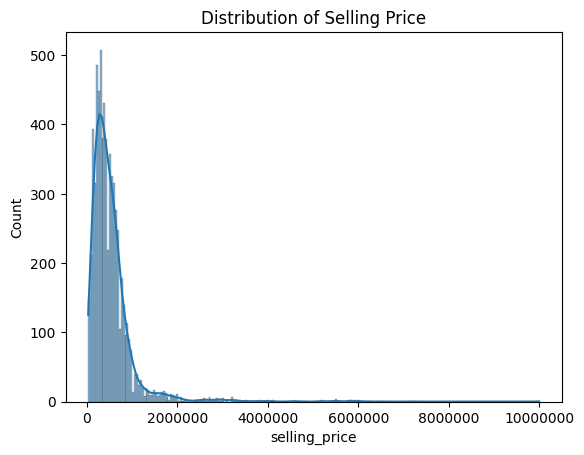

In [48]:
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Price")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight:**

The selling price distribution is right-skewed,

indicating most cars are in the lower price range

with few expensive outliers.

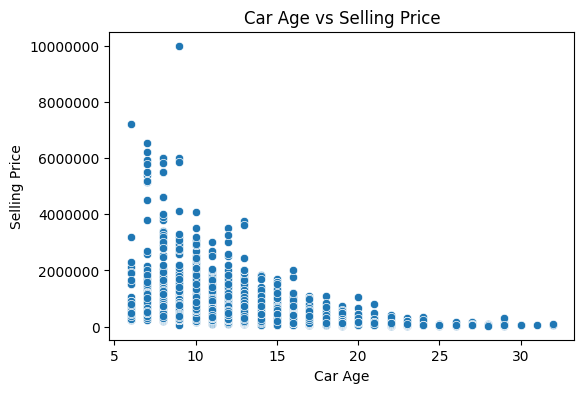

In [49]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["car_age"], y=df["selling_price"])
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight:**

There is a negative relationship between car age

and price-older cars age increases then selling

price becomes lower.

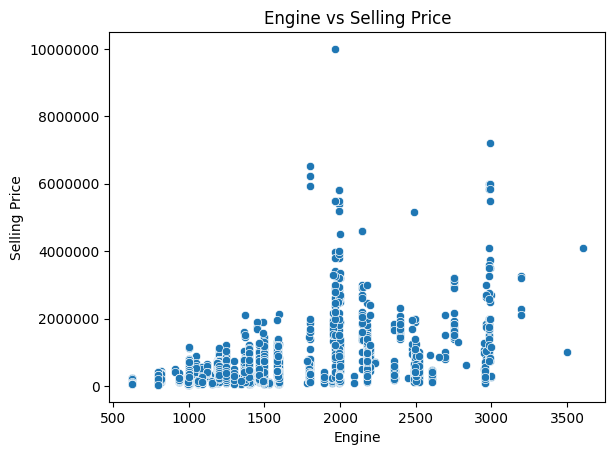

In [50]:
plt.figure()
sns.scatterplot(x=df["engine"], y=df["selling_price"])
plt.xlabel("Engine")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


**Insight:**

Engine size shows a positive correlation with price,

 meaning higher engine capacity cars tend to be more expensive.

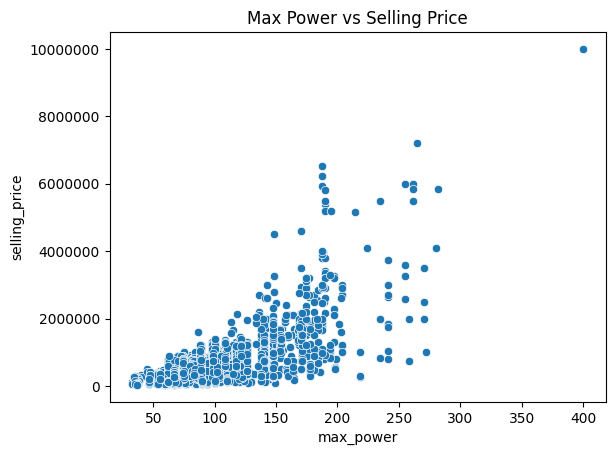

In [51]:
sns.scatterplot(x=df["max_power"], y=df["selling_price"])
plt.title("Max Power vs Selling Price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight:**

Cars with higher max power generally have higher selling prices.

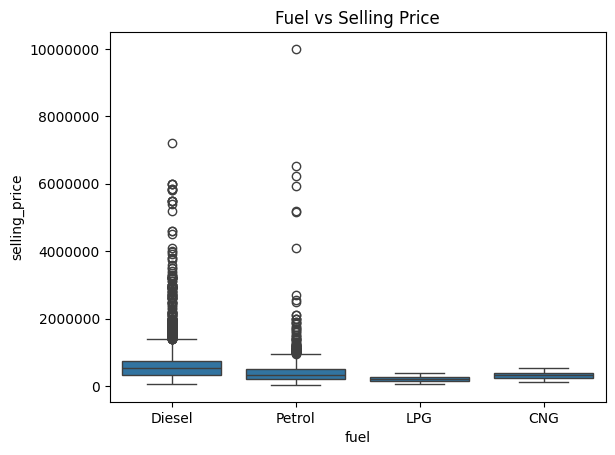

In [52]:
sns.boxplot(x=df["fuel"], y=df["selling_price"])
plt.title("Fuel vs Selling Price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight:**

Diesel cars tend to have slightly higher median prices compared to petrol cars.

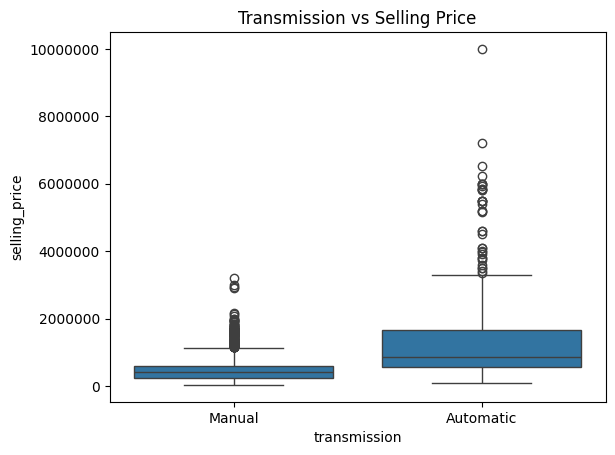

In [53]:
sns.boxplot(x=df["transmission"], y=df["selling_price"])
plt.title("Transmission vs Selling Price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight:**

Automatic cars generally have higher prices compared to manual cars

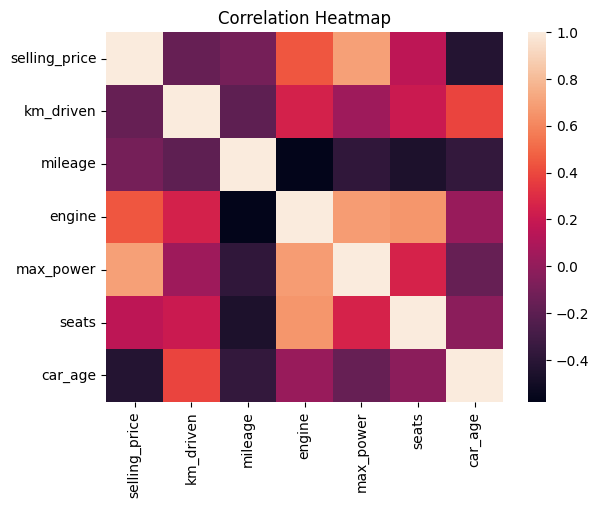

In [54]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()


**Insight:**


Correlation analysis is only applicable to numerical features,
so I filtered numeric columns before generating the heatmap.

Features like engine and max_power show strong positive correlation with price,

while car_age shows negative correlation

### **STEP 6 — Visualize Outliers | Remove**

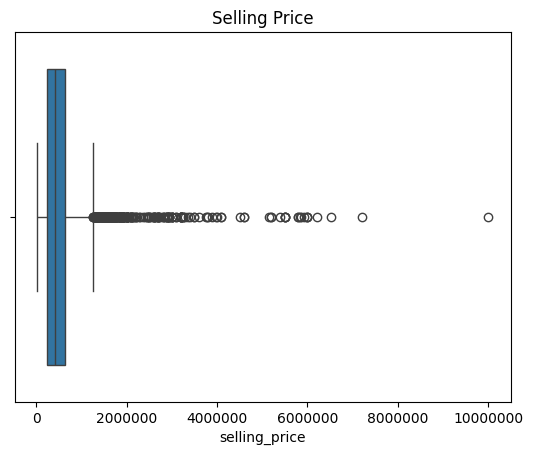

In [55]:
plt.figure()
sns.boxplot(x=df["selling_price"])
plt.title("Selling Price")
plt.ticklabel_format(style="Plain", axis="x")
plt.show()

**Note:**

I first perform EDA to identify outliers visually, then

decide whether to remove or cap them based on business logic.

In [56]:
print(df["selling_price"].min())
print(df["selling_price"].max())
print(df["selling_price"].mean())

29999
10000000
526385.9970224802


In [57]:
df.describe()

,selling_price,km_driven,mileage,engine,max_power,seats,car_age
count,6.717000e+03,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000
mean,5.263860e+05,7.339834e+04,19.466585,1430.985857,87.766100,5.434271,12.388864
std,5.235504e+05,5.870328e+04,4.048102,493.469198,31.724555,0.983805,3.897402
min,2.999900e+04,1.000000e+00,0.000000,624.000000,32.800000,2.000000,6.000000
25%,2.500000e+05,3.800000e+04,16.800000,1197.000000,67.100000,5.000000,9.000000
50%,4.200000e+05,6.820300e+04,19.440000,1248.000000,81.830000,5.000000,12.000000
75%,6.500000e+05,1.000000e+05,22.500000,1498.000000,100.000000,5.000000,15.000000
max,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000,32.000000


In [58]:
Q1 = df["selling_price"].quantile(0.25)
Q3 = df["selling_price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


print(lower_limit, upper_limit)

-350000.0 1250000.0


In [59]:
# To see how many outliers exist in the data

outliers = df[(df["selling_price"] < lower_limit) | (df["selling_price"] > upper_limit)]
print(f"Total number of outliers: {len(outliers)}")

Total number of outliers: 306


In [60]:
df = df[(df['selling_price'] >= lower_limit) & (df['selling_price'] <= upper_limit)]

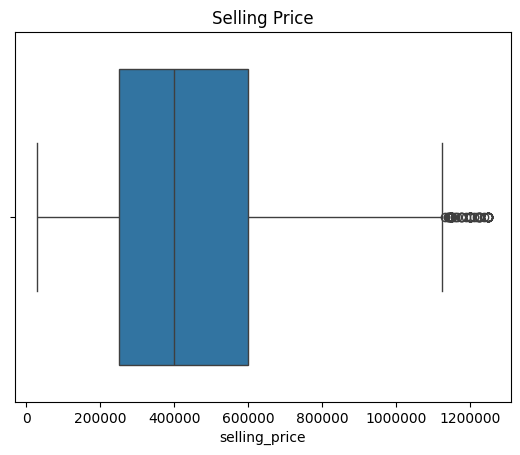

In [61]:
plt.figure()
sns.boxplot(x=df["selling_price"])
plt.title("Selling Price")
plt.ticklabel_format(style="Plain", axis="x")
plt.show()

In [62]:
print(df["selling_price"].min())
print(df["selling_price"].max())
print(df["selling_price"].mean())

29999
1250000
443622.6407736703


### **STEP 7 — Encoding (Categorical → Numeric)**

In [63]:
df = pd.get_dummies(df, drop_first=True)

In [64]:
df.head()

,selling_price,km_driven,mileage,engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,450000,145500,23.40,1248,74.00,5,12,True,False,False,True,False,True,False,False,False
1,370000,120000,21.14,1498,103.52,5,12,True,False,False,True,False,True,False,True,False
2,158000,140000,17.70,1497,78.00,5,20,False,False,True,True,False,True,False,False,True
3,225000,127000,23.00,1396,90.00,5,16,True,False,False,True,False,True,False,False,False
4,130000,120000,16.10,1298,88.20,5,19,False,False,True,True,False,True,False,False,False


### **STEP 8 — Feature Selection**

In [65]:
# Seeing correlation with target - Check Correlation First

corr = df.corr()['selling_price'].sort_values(ascending=False)
print(corr)

selling_price                   1.000000
max_power                       0.554518
engine                          0.379719
fuel_Diesel                     0.334692
seats                           0.257611
mileage                         0.078280
seller_type_Trustmark Dealer    0.056810
fuel_LPG                       -0.068171
owner_Fourth & Above Owner     -0.131709
km_driven                      -0.157635
seller_type_Individual         -0.163697
owner_Third Owner              -0.184586
transmission_Manual            -0.211545
owner_Second Owner             -0.219552
fuel_Petrol                    -0.317297
car_age                        -0.630203
Name: selling_price, dtype: float64


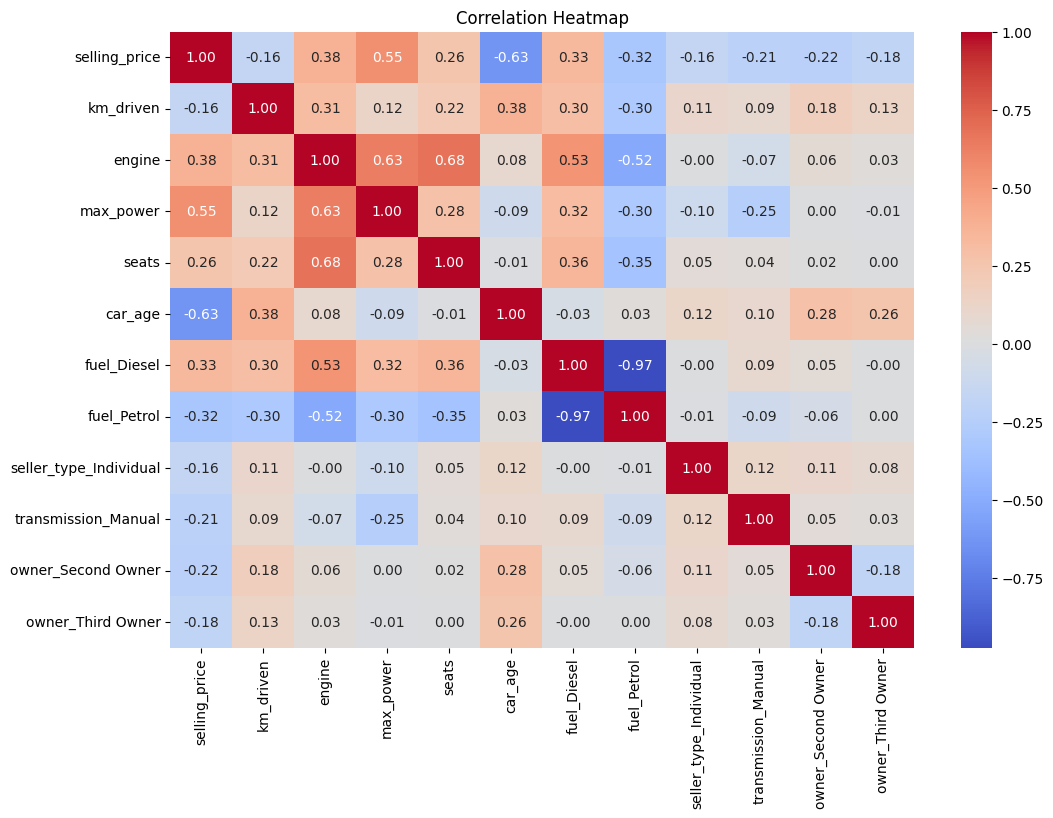

In [83]:
# Visualize Correlation (Heatmap)

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [67]:
df = df.drop(columns=["mileage", "seller_type_Trustmark Dealer", "fuel_LPG",
                      "owner_Fourth & Above Owner"])

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['selling_price', 'km_driven', 'engine', 'max_power', 'seats', 'car_age', 'fuel_Diesel', 'fuel_Petrol', 'seller_type_Individual', 'transmission_Manual', 'owner_Second Owner', 'owner_Third Owner']


In [68]:
x = df.drop(columns=["selling_price"])
y = df["selling_price"]

In [69]:
x.shape

(6411, 11)

In [70]:
y.shape

(6411,)

### **STEP 9 — Train-Test Split**

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [72]:
print(X_train.shape)
print(X_test.shape)

(5128, 11)
(1283, 11)


In [73]:
print(y_train.shape)
print(y_test.shape)

(5128,)
(1283,)


### **STEP 10 — Model Building (Random Forest)**


In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

### **STEP 11 — Prediction**

In [88]:
y_pred = model.predict(X_test)

In [77]:
print(f"Predicted: {y_pred[:5]}")
print(f"Actual {y_test[:5].values}")

Predicted: [482339.59  763299.99  413920.    237449.97  477314.985]
Actual [350000 800000 346000 110000 475000]


### **STEP 12 — Model Evaluation**

**Car price depends on:**

> → Engine + Max Power + Car Age

> → Engine + Max Power + Car Age

> → ALL TOGETHER at the same time

> → Not a simple straight line

> → Random Forest handles this well



In [90]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8714897126323892


Why Random Forest?
→ "Because my data is complex and
   Linear Regression only gave 0.67
   Random Forest gave 0.87"




---


Why drop those columns?
→ "Because their correlation was
   close to 0, meaning they had
   no relationship with selling price"



---


What is R2 Score?
→ "It tells how accurate my model is
   My model is 87% accurate" ✅

### **STEP 13 — Visualization**

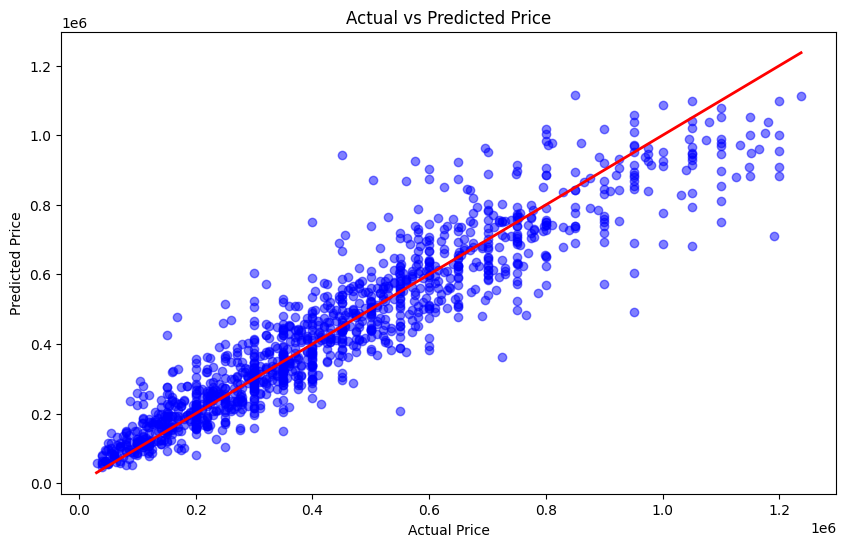

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

### **STEP 14 — Model Interpretation**

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False)
print(importance.sort_values(ascending=False))


car_age                   0.437075
max_power                 0.340681
engine                    0.130353
km_driven                 0.055596
seats                     0.010268
owner_Second Owner        0.006848
fuel_Diesel               0.004816
seller_type_Individual    0.004304
transmission_Manual       0.004279
fuel_Petrol               0.003463
owner_Third Owner         0.002317
dtype: float64


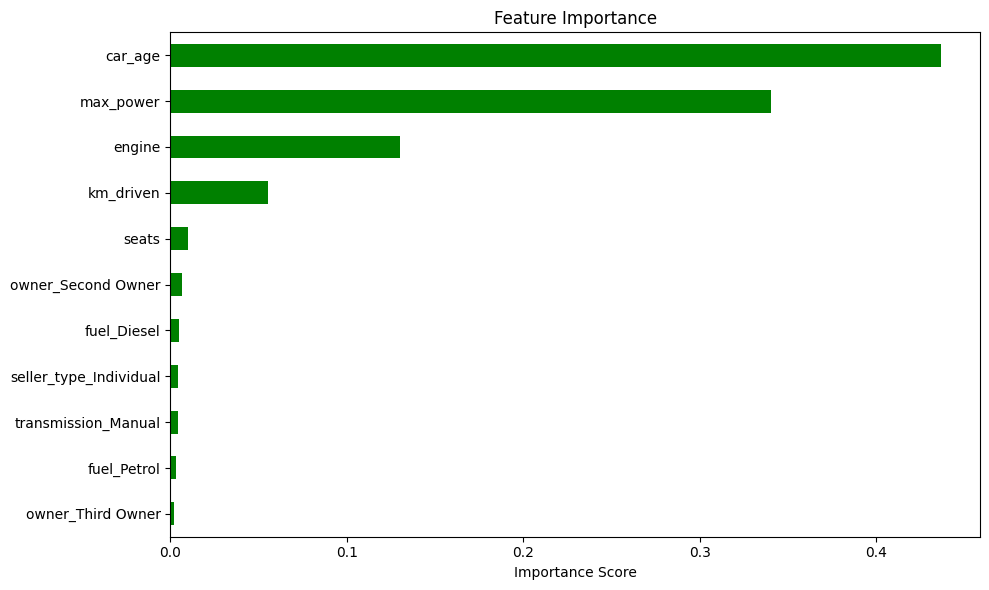

In [94]:
importance.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    color='green'
)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### **STEP 15 — Save Model**

In [95]:
import pickle

# Save the model
with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
"""# Load the model
with open('car_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Model Loaded Successfully!")

# Use it to predict
y_pred_new = loaded_model.predict(X_test)
print("Predictions:", y_pred_new[:5])"""

### **STEP 16 — Conclusion**


I wanted to predict the selling price
of a used car based on its features
like engine, max power, car age etc.

> **STEP 1** - Import Libraries

> **STEP 2** - Load Dataset | Understanding

> **STEP 3** - Data Cleaning

> **STEP 4** - Feature Engineering (car_age)

> **STEP 5** - EDA

> **STEP 6** - Visualize Outliers | Remove

> **STEP 7** - Encoding (Categorical - Numeric)

> **STEP 8** - Feature Selection (correlation)

> **STEP 9** - Train Test Split (80/20)

> **STEP 10** - Model Building (Random Forest) → 0.87

> **STEP 11** - Prediction

> **STEP 11** - Model Evaluation

> **STEP 13** - Visualization

> **STEP 14** - Model Interpretation

> **STEP 15** - Save Model

> **STEP 16** - Conclusion